# Regression Analysis of Housing Prices
----
##### John E. Llenarez

### Introduction:

This analysis is important to provide general insights for real estate investment. We will use various analysis and diagnosis to predict the future price of a housing prices in the California.

### Libraries

In [12]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA

from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust import norms
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV

### California Housing Dataset


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df['MedHouseVal'] = housing.target

print("Dataset description:\n", housing.DESCR)
print("\nFirst 5 rows of the dataset:")
display(df.head())
print("\nDataset info:")
df.info()

Dataset description:
 .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Notice that there is a column with `AveRooms` and `AveBedrms` which is nearly identical, also we hace `Latitude` and `Longitude` that is linked together, this (might) affect our prediction if the regression treat them separetedly.

In [44]:
df.columns

Index(['MedInc', 'HouseAge', 'BedrmsPerRoom', 'LogMedHouseVal',
       'LogPopulation', 'LogAveOccup', 'Location_PCA'],
      dtype='object')

Lets open a map!

In [3]:
fig = px.scatter_mapbox(
    df,
    lat=df["Latitude"],
    lon=df["Longitude"],
    width=800,
    height=500,
    color="MedHouseVal",
    hover_data=["MedHouseVal"]
)
fig.update_layout(mapbox_style="open-street-map")

fig.show()

In the map, you can see that most of the houses near the coastline are valued higher than the other location.

## Exploratory Data Analysis

### Histoplots

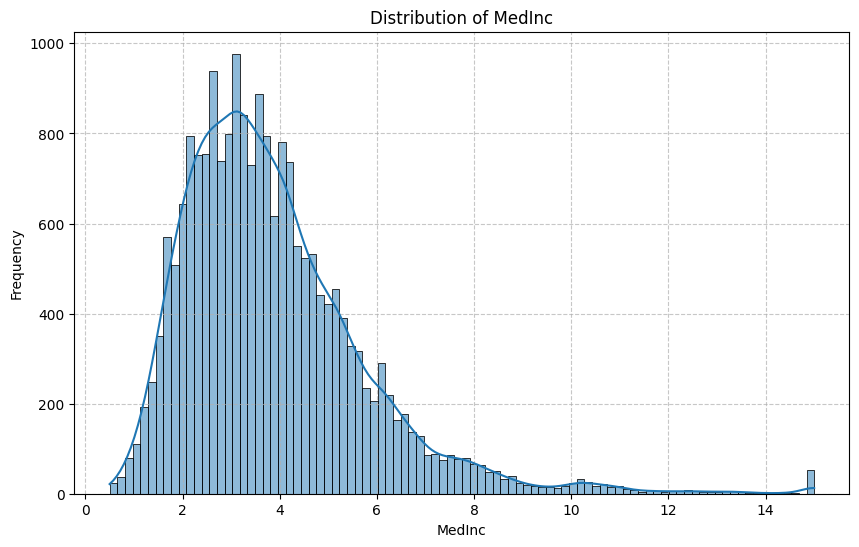

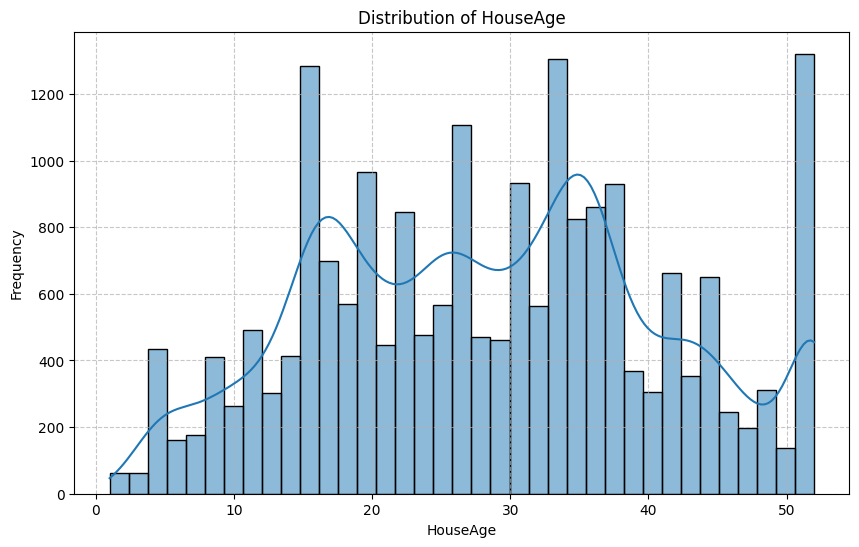

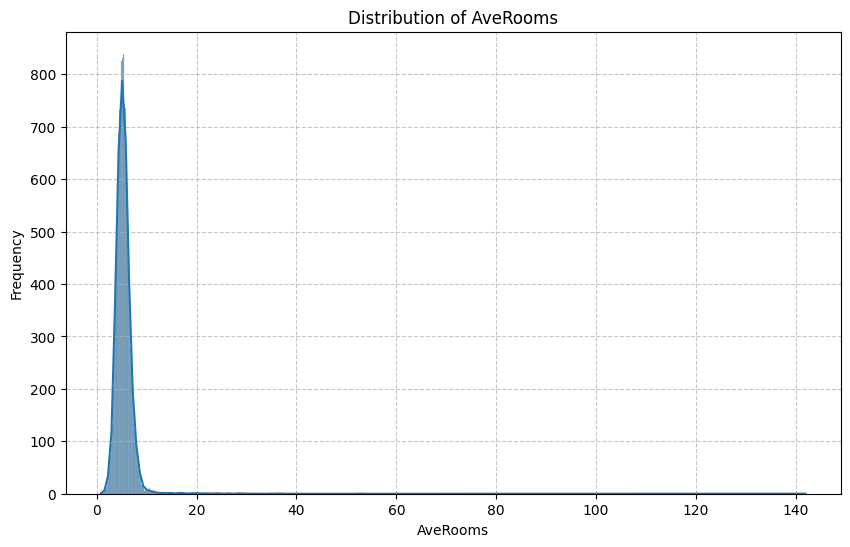

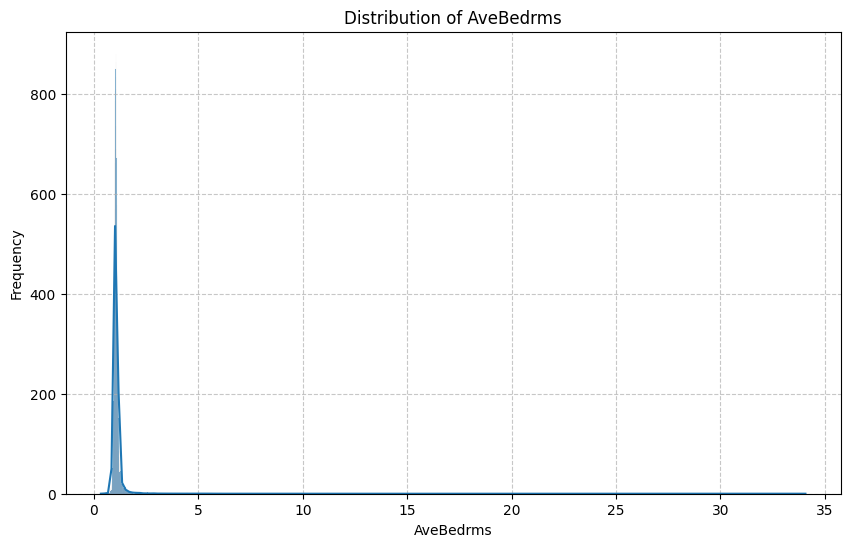

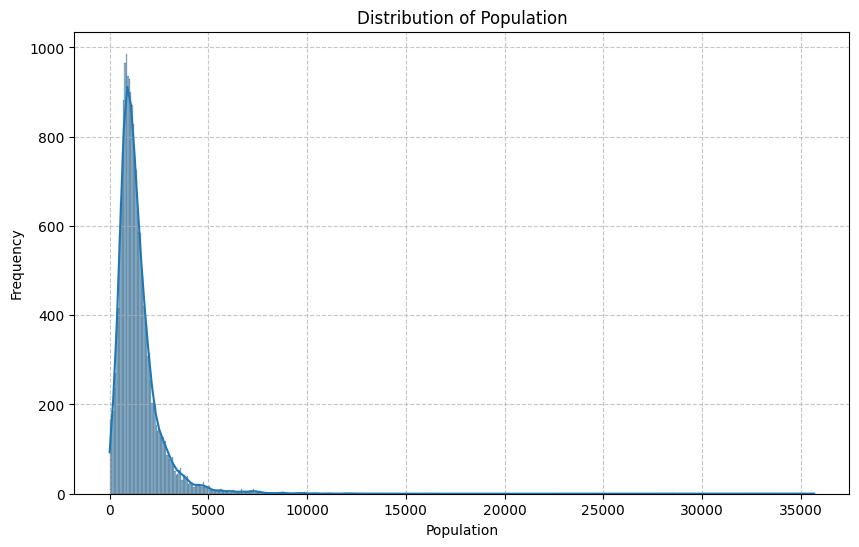

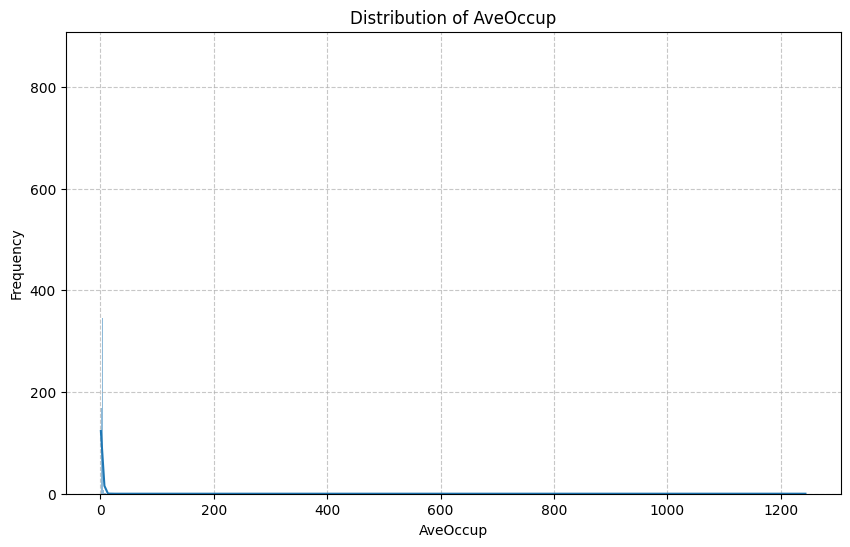

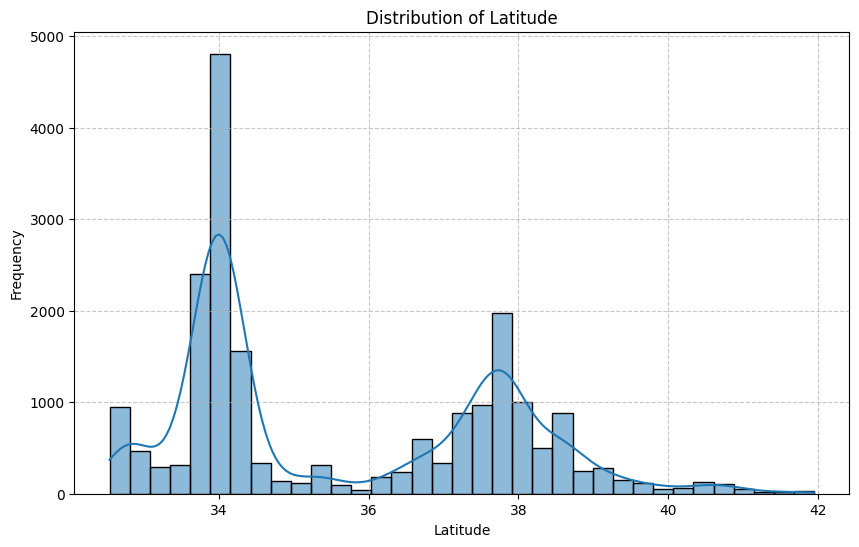

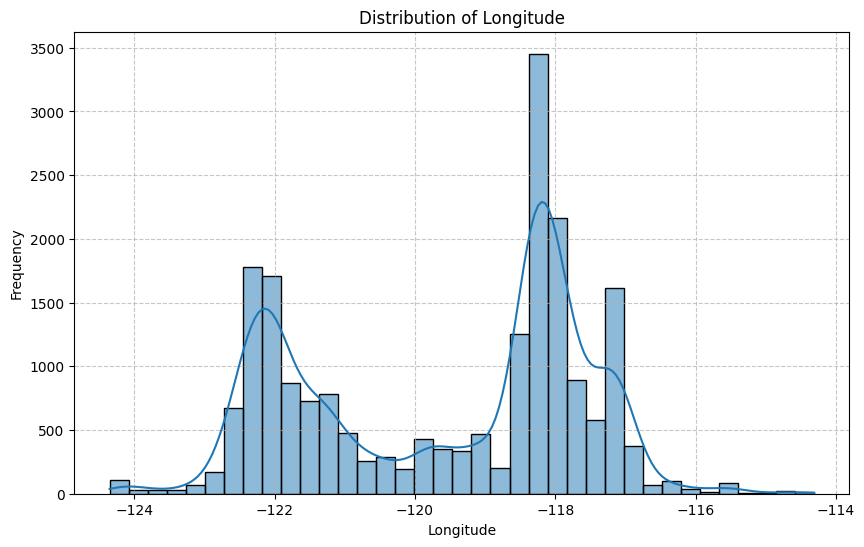

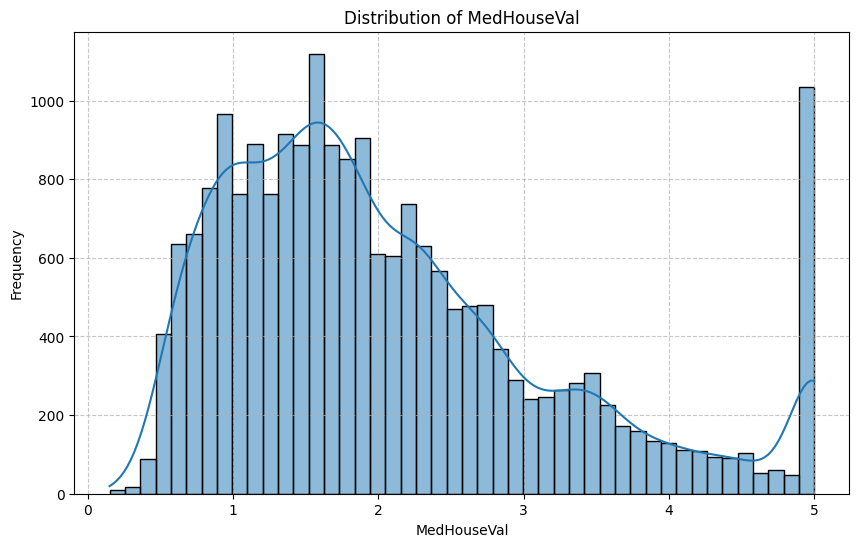

In [4]:
for column in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(f'{column}_histogram.png')
    plt.show()

Most of the data is skewed. The `HouseAge` looks multimodal. The `AveOccup` looks weird in the histoplot. Lastly, Latitude and Longitude looks random because they are just coordinates.

### Box Plots

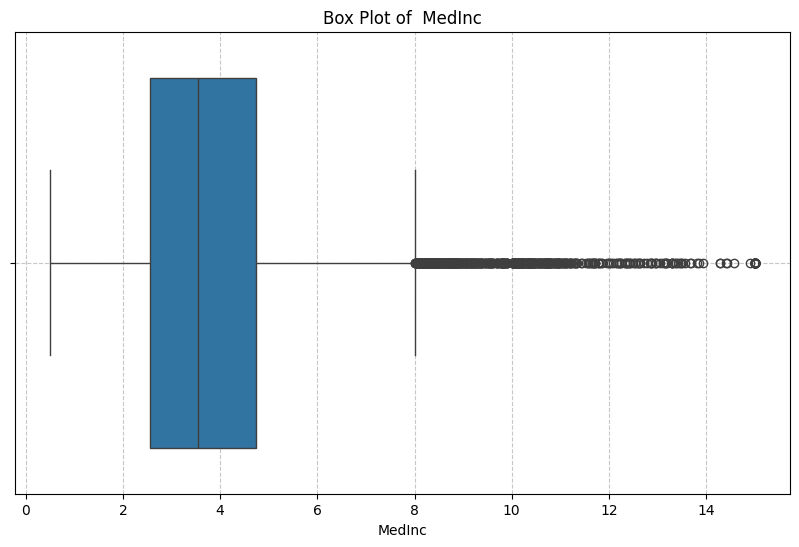

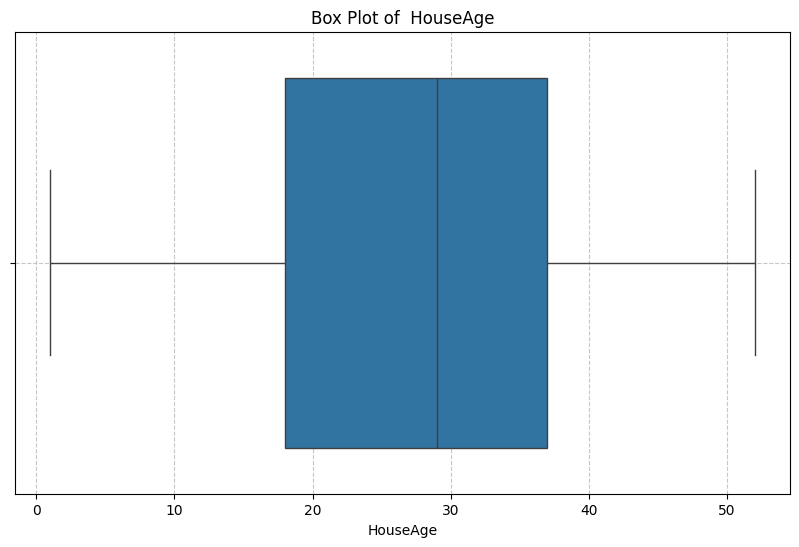

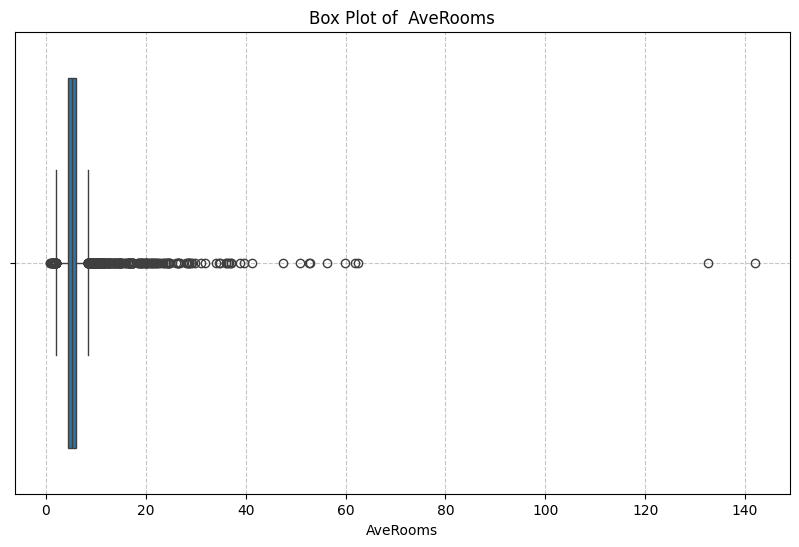

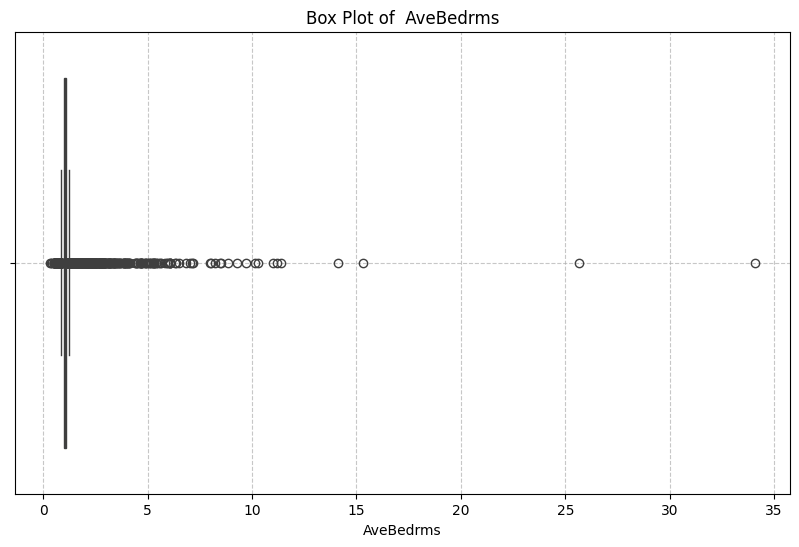

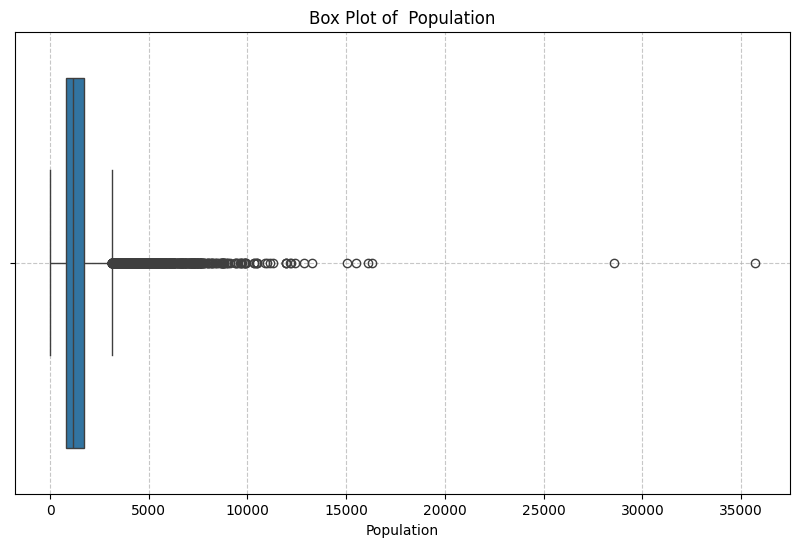

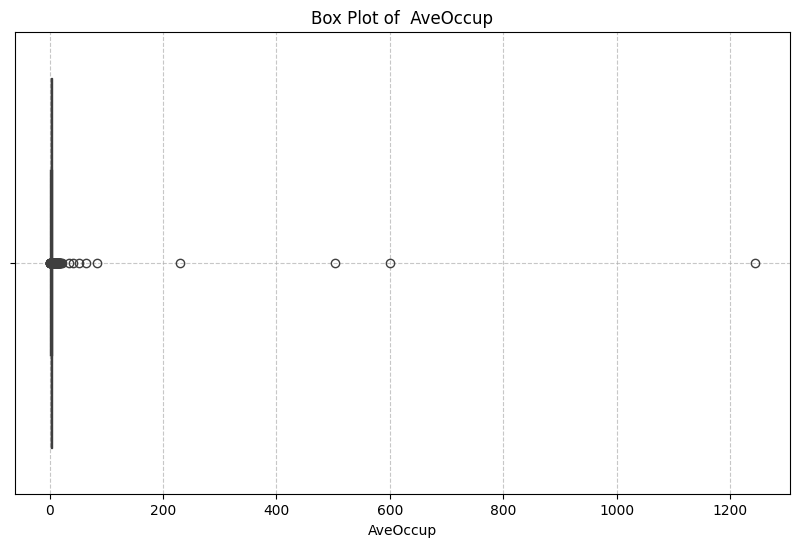

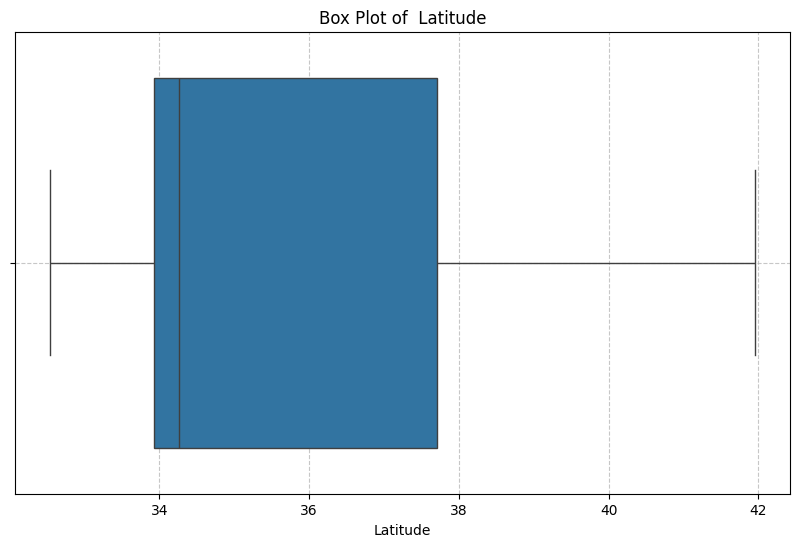

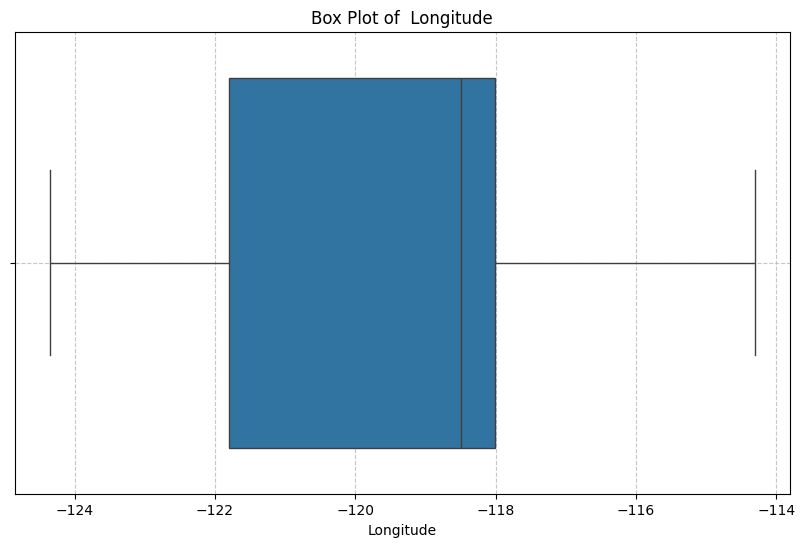

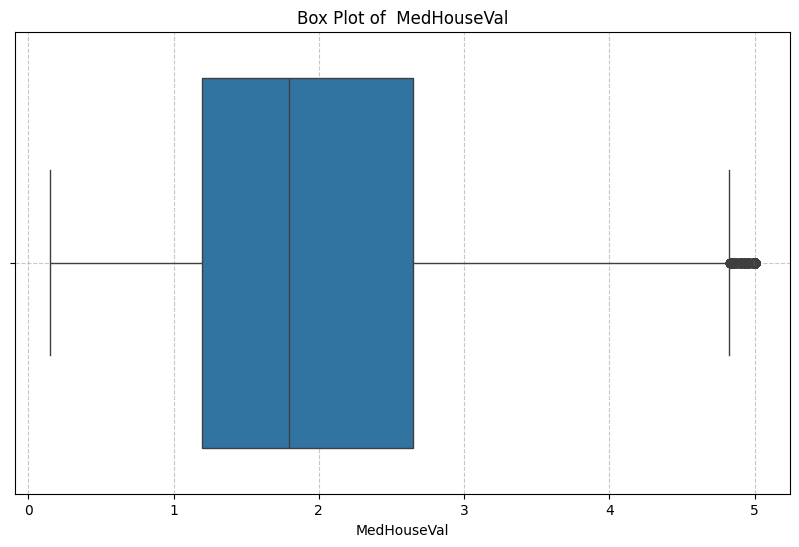

In [5]:
for column in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of  {column}')
    plt.xlabel(column)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(f'{column}_boxplot.png')
    plt.show()

Most of the boxplots normal but there are some severe outliers in `AveOccup` that explains why it looks abnormal in the histogram.

### Correlation Matrix

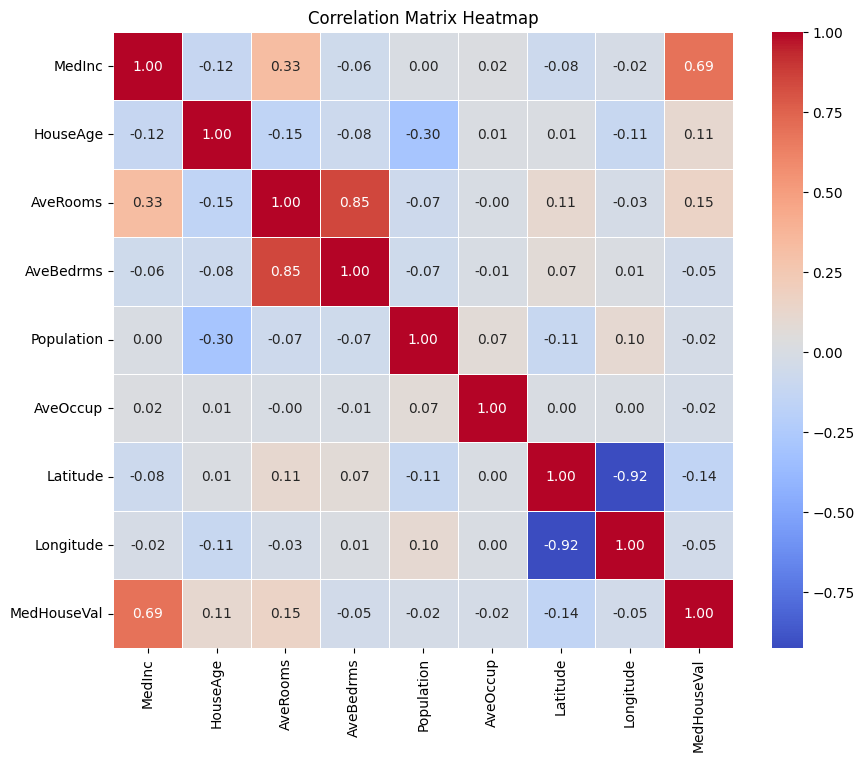

In [6]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

The correlation heatmap shows the correlation of the data, the heavier the color means it has a high correlation, while the lighter the color means it has a low correlation. Red means positive correlation and Blue means negative correlation.

Given the high correlation between `AveRooms` and `AveBedrms`, creating a ratio of bedrooms per room (`BedrmsPerRoom`) can be a more informative feature since big house have both more of both and small house have less of both. Combining them is a better approach. This helps to capture the dwelling's composition more directly and can mitigate multicollinearity issues. We will then consider dropping the original `AveRooms` and `AveBedrms` columns, if we decide to use this new ratio feature.

First 5 rows with new BedrmsPerRoom variable:


,AveRooms,AveBedrms,BedrmsPerRoom
0,6.984127,1.023810,0.146591
1,6.238137,0.971880,0.155797
2,8.288136,1.073446,0.129516
3,5.817352,1.073059,0.184458
4,6.281853,1.081081,0.172096


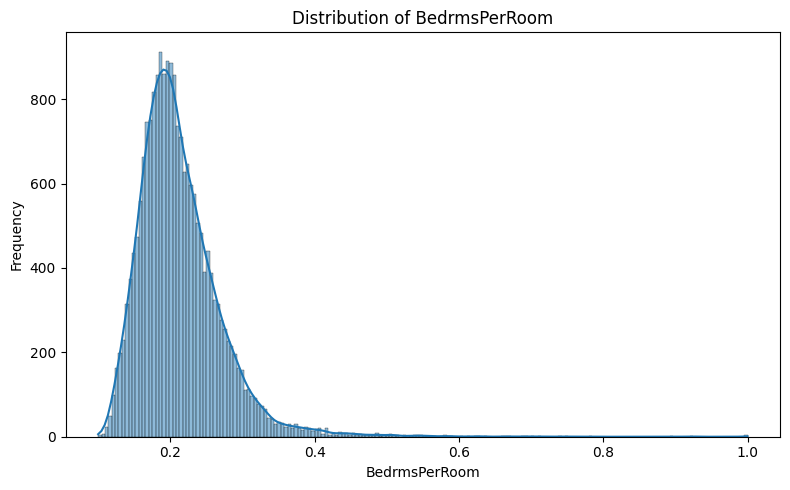

In [7]:
df['BedrmsPerRoom'] = df['AveBedrms'] / df['AveRooms']

print("First 5 rows with new BedrmsPerRoom variable:")
display(df[['AveRooms', 'AveBedrms', 'BedrmsPerRoom']].head())

# Visualize the distribution of BedrmsPerRoom
plt.figure(figsize=(8, 5))
sns.histplot(df['BedrmsPerRoom'], kde=True)
plt.title('Distribution of BedrmsPerRoom')
plt.xlabel('BedrmsPerRoom')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('BedrmsPerRoom_histogram.png')
plt.show()

### Log Transformation of Target Variable

We will log transform the `MedHouseVal` (Median House Value) to address its right-skewed distribution. This often helps in making the residuals of a regression model more normally distributed and can improve model assumptions.

First 5 rows with LogMedHouseVal:


,MedHouseVal,LogMedHouseVal
0,4.526,1.709464
1,3.585,1.522790
2,3.521,1.508733
3,3.413,1.484555
4,3.422,1.486592


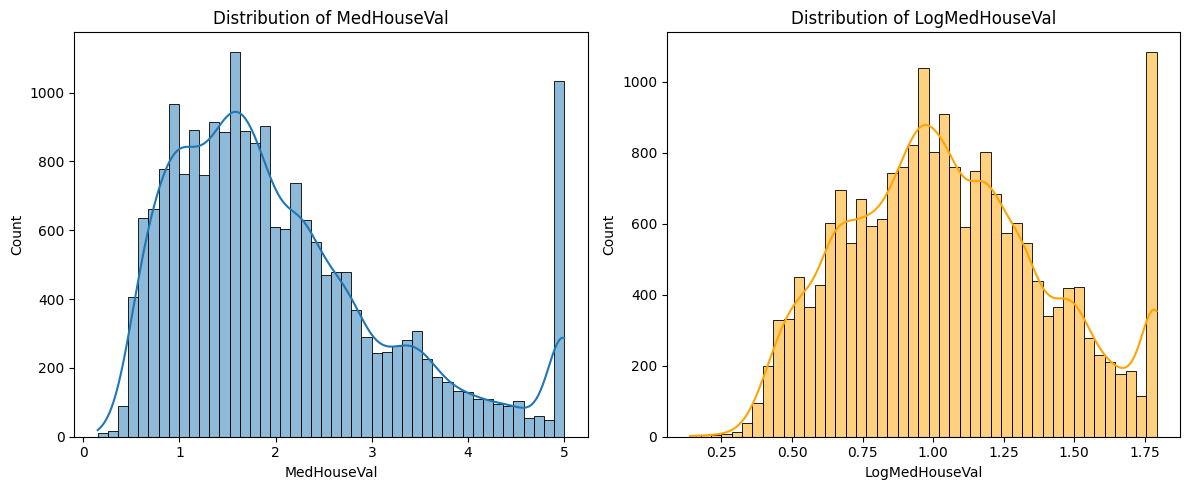

In [8]:
df['LogMedHouseVal'] = np.log1p(df['MedHouseVal'])

print("First 5 rows with LogMedHouseVal:")
display(df[['MedHouseVal', 'LogMedHouseVal']].head())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], kde=True)
plt.title('Distribution of MedHouseVal')

plt.subplot(1, 2, 2)
sns.histplot(df['LogMedHouseVal'], kde=True, color='orange')
plt.title('Distribution of LogMedHouseVal')

plt.tight_layout()
plt.show()

### Handling Capped Median House Values

The `MedHouseVal` in this dataset is known to be capped at 5.0 (representing $500,000). To avoid bias from this artificial ceiling, we will remove rows where `MedHouseVal` is exactly 5.0, allowing our models to learn from the uncapped distribution.

Original number of rows: 20640
Number of rows after filtering capped values: 19648
Number of rows removed: 992


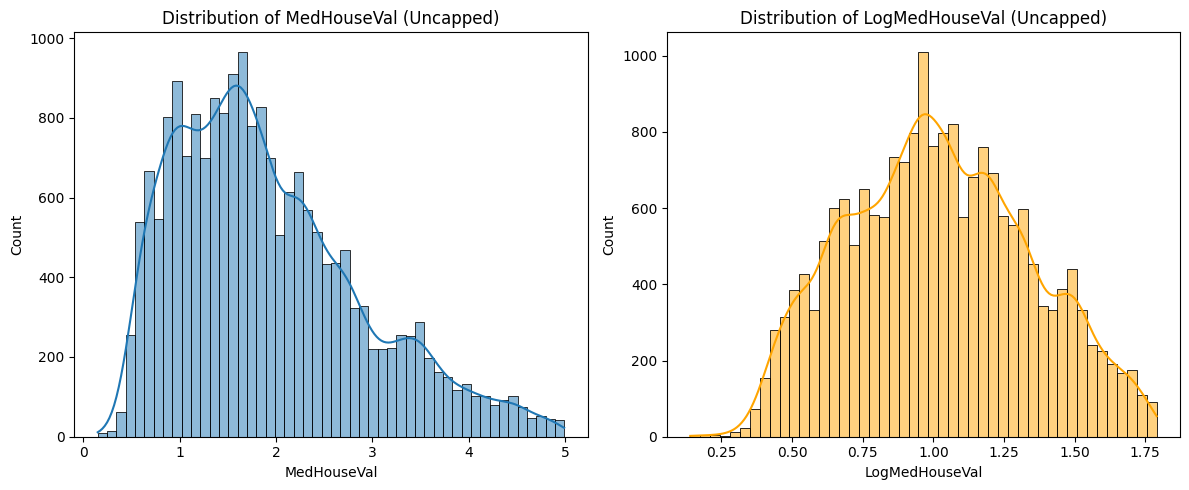

In [9]:
original_rows = len(df)
df = df[df['MedHouseVal'] < 5.0]
filtered_rows = len(df)

print(f"Original number of rows: {original_rows}")
print(f"Number of rows after filtering capped values: {filtered_rows}")
print(f"Number of rows removed: {original_rows - filtered_rows}")

# Re-visualize the distribution of MedHouseVal and LogMedHouseVal after filtering
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], kde=True)
plt.title('Distribution of MedHouseVal (Uncapped)')

plt.subplot(1, 2, 2)
sns.histplot(df['LogMedHouseVal'], kde=True, color='orange')
plt.title('Distribution of LogMedHouseVal (Uncapped)')

plt.tight_layout()
plt.show()

### Log Transformation of Exogenous Variables

Given the skewed distributions of `Population`, and `AveOccup`, we will apply a log transformation (specifically `np.log1p` which is `log(1+x)`) to these variables. This helps in normalizing their distributions, making them more suitable for linear regression models and potentially improving model performance. For `MedInc` and `BedrmsPerRooms` lets see first before transforming them.

In [10]:
df['LogPopulation'] = np.log1p(df['Population'])
df['LogAveOccup'] = np.log1p(df['AveOccup'])

print("First 5 rows with new log-transformed exogenous variables:")
display(df[['Population', 'LogPopulation', 'AveOccup', 'LogAveOccup']].head())

First 5 rows with new log-transformed exogenous variables:


/tmp/ipykernel_2991/726935701.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2991/726935701.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Population,LogPopulation,AveOccup,LogAveOccup
0,322.0,5.777652,2.555556,1.268511
1,2401.0,7.784057,2.109842,1.134572
2,496.0,6.208590,2.802260,1.335596
3,558.0,6.326149,2.547945,1.266369
4,565.0,6.338594,2.181467,1.157342


### Principal Component Analyis

For the corrdinates, we should use PCA to `Latitude` and `Longitude`. PCA retains most of the predictive power of the coordinates. This also removes the collinearity of both since it makes them perpendicular to each other.

In [13]:
# Initialize StandardScaler
scaler = StandardScaler()

# Select Latitude and Longitude for PCA
coords = df[['Latitude', 'Longitude']]

# Scale the coordinates
scaled_coords = scaler.fit_transform(coords)

# Initialize PCA with 1 component
pca = PCA(n_components=1)

# Fit PCA and transform the scaled coordinates
df['Location_PCA'] = pca.fit_transform(scaled_coords)

print("First 5 rows with new Location_PCA variable:")
display(df[['Latitude', 'Longitude', 'Location_PCA']].head())

print("DataFrame columns after dropping original coordinates:")
print(df.columns)

First 5 rows with new Location_PCA variable:


/tmp/ipykernel_2991/902382504.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Latitude,Longitude,Location_PCA
0,37.88,-122.23,-1.673260
1,37.86,-122.22,-1.663157
2,37.85,-122.24,-1.666919
3,37.85,-122.25,-1.670445
4,37.85,-122.25,-1.670445


DataFrame columns after dropping original coordinates:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'BedrmsPerRoom',
       'LogMedHouseVal', 'LogPopulation', 'LogAveOccup', 'Location_PCA'],
      dtype='object')


In [14]:
print(f"Explained variance ratio of the single PCA component: {pca.explained_variance_ratio_[0]*100:.2f}%")

Explained variance ratio of the single PCA component: 96.21%


Now, lets examine our dataframe again and drop some of the original columns.

In [15]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'BedrmsPerRoom',
       'LogMedHouseVal', 'LogPopulation', 'LogAveOccup', 'Location_PCA'],
      dtype='object')

In [16]:
#Drop MedHouseVal because we already have their log
df = df.drop(columns=['MedHouseVal'])

In [17]:
#Drop original AveRooms and AveBedrms as BedrmsPerRoom is now available
df = df.drop(columns=['AveRooms', 'AveBedrms'])

# Drop original Latitude and Longitude as they are now represented by PCA
df = df.drop(columns=['Latitude', 'Longitude'])

# Drop the original exogenous variables that have been log-transformed
df = df.drop(columns=['Population', 'AveOccup'])

In [18]:
df.head()

,MedInc,HouseAge,BedrmsPerRoom,LogMedHouseVal,LogPopulation,LogAveOccup,Location_PCA
0,8.3252,41.0,0.146591,1.709464,5.777652,1.268511,-1.673260
1,8.3014,21.0,0.155797,1.522790,7.784057,1.134572,-1.663157
2,7.2574,52.0,0.129516,1.508733,6.208590,1.335596,-1.666919
3,5.6431,52.0,0.184458,1.484555,6.326149,1.266369,-1.670445
4,3.8462,52.0,0.172096,1.486592,6.338594,1.157342,-1.670445


### Re-examine Correlation Matrix

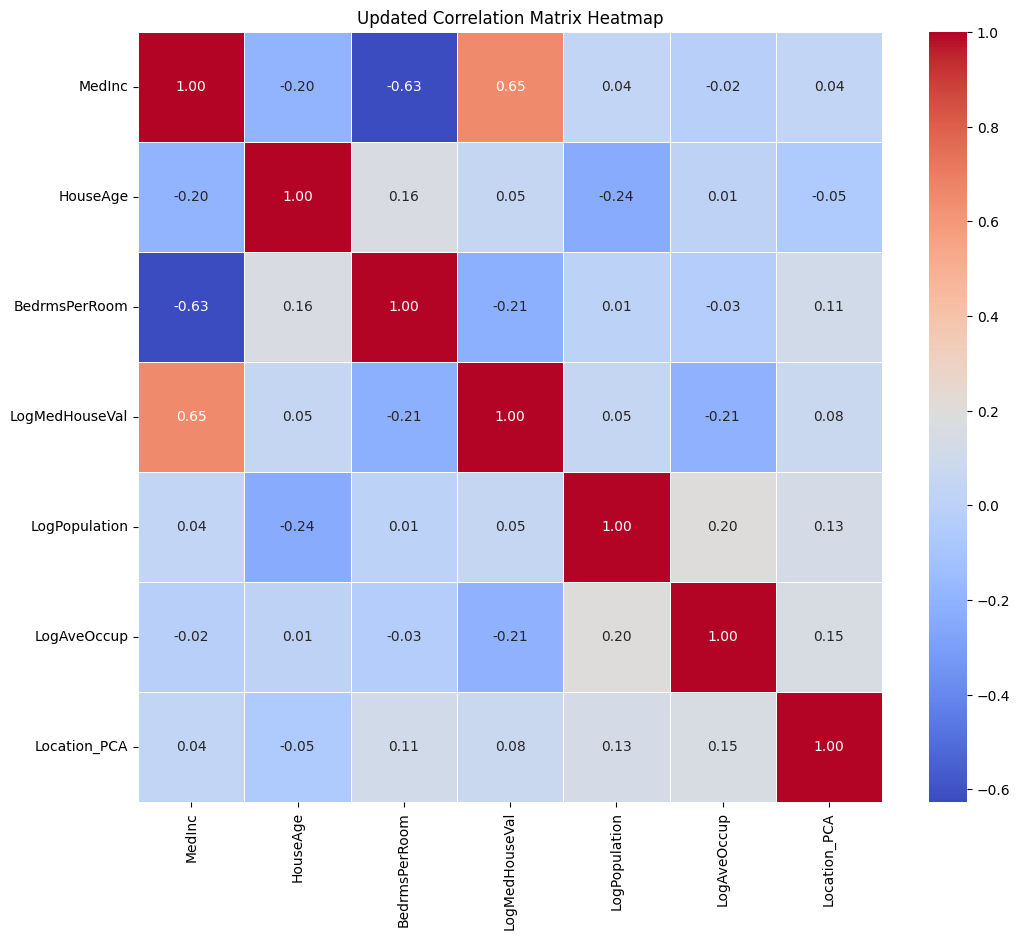

In [19]:
updated_correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(updated_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Updated Correlation Matrix Heatmap')
plt.show()

The heatmap shows `MedInc` is still highly correlated with `BedrmsPerRoom`.

### Variance Inflation Factor

In [20]:
exogenous = [col for col in df.columns if col != "LogMedHouseVal"]
variables = df[exogenous].values
labels = df[exogenous].columns

vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
pd.DataFrame(vif, labels, columns=["VIF"])

,VIF
MedInc,8.567102
HouseAge,6.149200
BedrmsPerRoom,19.936443
LogPopulation,59.979623
LogAveOccup,40.557963
Location_PCA,1.021077


VIF with greater than 5 has multicollinearity issue, it might be better to remove one of them to address this or we might need to use standard scaler to standardized them all.

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[exogenous])

In [22]:
exogenous = [col for col in df.columns if col != "LogMedHouseVal"]
variables = X_scaled
labels = exogenous

vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
pd.DataFrame(vif, labels, columns=["VIF"])

,VIF
MedInc,1.711043
HouseAge,1.113611
BedrmsPerRoom,1.719310
LogPopulation,1.124213
LogAveOccup,1.072835
Location_PCA,1.072415


### Ordinary Least Square
Now that we have the data lets run a basic regression

In [23]:
exogenous = [col for col in df.columns if col != "LogMedHouseVal"]
df_X = X_scaled
df_y = df["LogMedHouseVal"]

df_X_const = sm.add_constant(df_X)

ols_model = sm.OLS(df_y, df_X_const)
ols_results1 = ols_model.fit()

print(ols_results1.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMedHouseVal   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     4242.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:54:07   Log-Likelihood:                 2466.2
No. Observations:               19648   AIC:                            -4918.
Df Residuals:                   19641   BIC:                            -4863.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0190      0.002    669.126      0.0

All off our predictors are statistically significant and we have $R^2$ and $adjusted$ $R^2$ of 56.4%. This means 56.4% of the variation in Housing Price can be explained by our predictors. The remaining 43.6% can be explained by other factors that are not in the data.

### Residual Analysis
Let's plot the residuals against the fitted values to visually inspect for heteroscedasticity.

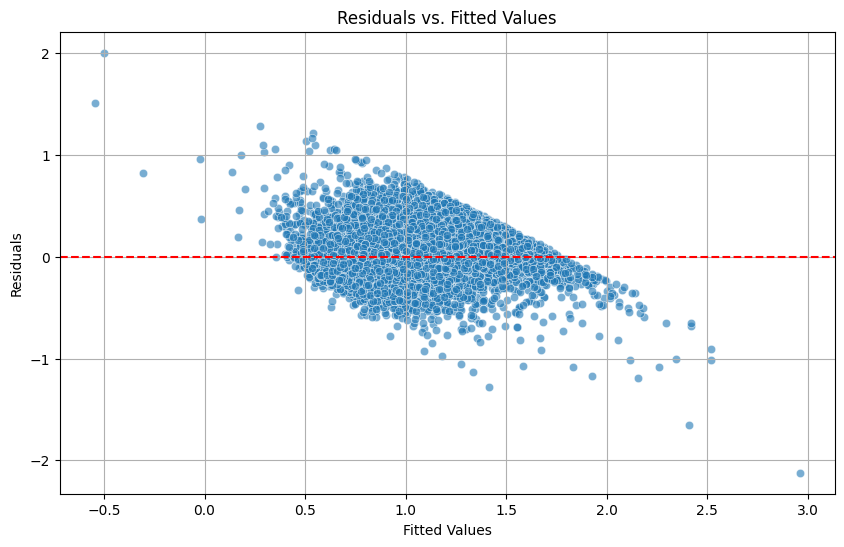

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ols_results1.fittedvalues, y=ols_results1.resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

The funnel shape in the residuals vs. fitted values plot confirms the presence of heteroscedasticity, as the spread of the residuals changes with the fitted values. Lets use Breusch-Pagan test to confirm the results.

### Breusch-Pagan Test

In [25]:
name = ["Lagrange multiplier statistic", "p-value", "f-value", "f p-value"]
exog_het = sm.add_constant(ols_results1.model.exog, prepend=False)
test = sms.het_breuschpagan(ols_results1.resid, exog_het)
pd.DataFrame(test, index=name, columns=[""])

,
Lagrange multiplier statistic,1.140347e+03
p-value,3.884033e-243
f-value,2.016964e+02
f p-value,1.596934e-250


Since the p-value is much, much smaller than 0.05, we reject the null hypothesis of homoscedasticity. This means we have statistically significant evidence to conclude that heteroscedasticity is present in the model's residuals.

In [26]:
log_sq_resid = np.log(ols_results1.resid**2)

var_model = sm.OLS(log_sq_resid, df_X_const).fit()

fitted_variance = np.exp(var_model.fittedvalues)
weights = 1.0 / fitted_variance

wls_model = sm.WLS(df_y, df_X_const, weights=weights)
wls_results = wls_model.fit()

print(wls_results.summary())

                            WLS Regression Results                            
Dep. Variable:         LogMedHouseVal   R-squared:                       0.504
Model:                            WLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     3331.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:54:25   Log-Likelihood:                 661.11
No. Observations:               19648   AIC:                            -1308.
Df Residuals:                   19641   BIC:                            -1253.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0155      0.002    592.007      0.0

The $R^2$ and $adjusted$ $R^2$ are a lower than standart OLS but WLS solved the hetescedasticity issue.

### Influential Points using Cook's Distance


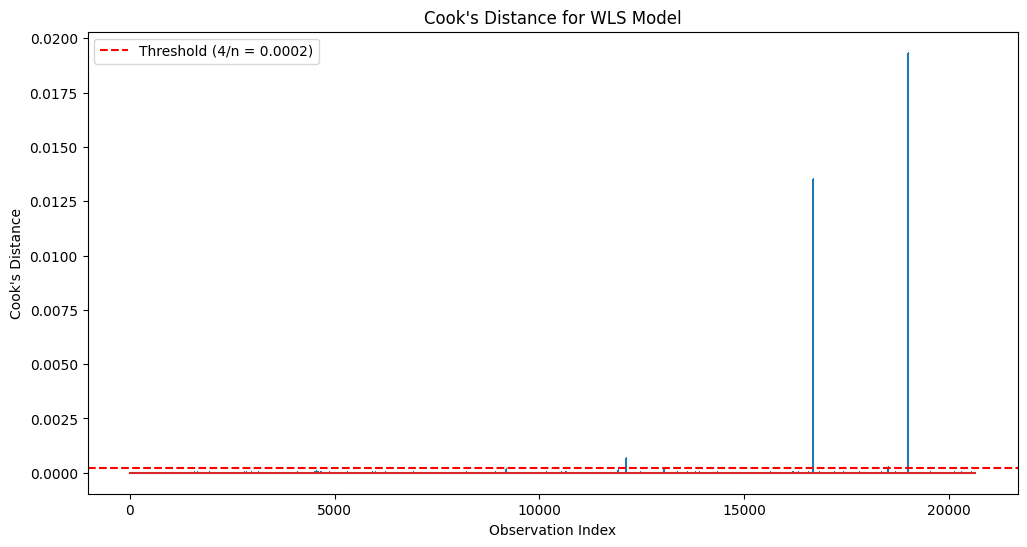

Number of influential points (Cook's D > 0.0002): 5


,Cooks_Distance,Observation
19006,0.019339,19006
16669,0.013534,16669
12104,0.000698,12104
18501,0.000241,18501
13034,0.000221,13034


In [27]:
# Calculate Cook's Distance for the WLS model manually
residuals = wls_results.resid
p = wls_results.df_model + 1  # wls + constant
mse_resid = wls_results.mse_resid


# matrix X_w = X * sqrt(W)
weighted_design_matrix = wls_model.exog * np.sqrt(wls_model.weights)[:, np.newaxis]

#  H = X_w * (X_w.T * X_w)^-1 * X_w.T, where X_w is the weighted design matrix
try:
    # Ensure the matrix multiplication is done correctly
    XTX_inv = np.linalg.inv(weighted_design_matrix.T @ weighted_design_matrix)
    hat_matrix_diag = np.diag(weighted_design_matrix @ XTX_inv @ weighted_design_matrix.T)
except np.linalg.LinAlgError:
    print("Warning: Weighted design matrix is singular, cannot calculate leverage directly. Cook's Distance might be inaccurate.")
    hat_matrix_diag = np.zeros_like(residuals)

# Cook's Distance
# D_i = (e_i^2 / (p * MSE)) * (h_ii / (1 - h_ii)^2)
# Add a small epsilon to (1 - hat_matrix_diag) to prevent division by zero for perfect leverage points
cook_d_wls = (residuals**2 / (p * mse_resid)) * (hat_matrix_diag / (1 - hat_matrix_diag + 1e-8)**2)

# Create a DataFrame for Cook's Distance
cooks_df_wls = pd.DataFrame({'Cooks_Distance': cook_d_wls, 'Observation': df.index})

# Plot Cook's Distance
plt.figure(figsize=(12, 6))
plt.stem(cooks_df_wls['Observation'], cooks_df_wls['Cooks_Distance'], markerfmt=",")
plt.title("Cook's Distance for WLS Model")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")

# Treshold 4/n
threshold = 4 / len(df)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')
plt.legend()
plt.show()

# Points above the threshold
influential_points_wls = cooks_df_wls[cooks_df_wls['Cooks_Distance'] > threshold]
print(f"Number of influential points (Cook's D > {threshold:.4f}): {len(influential_points_wls)}")

# Top influential points
if not influential_points_wls.empty:
    display(influential_points_wls.sort_values(by='Cooks_Distance', ascending=False).head())

Since we have 5 influncial points we should run a Robust Regression.

## Robust Regression
We have two methods to run a robust regression, Huber and Bisquare. Lets run them together and compare their result.

### Huber Method

In [28]:
#Ensuring we run huber over WLS
weights = wls_model.weights

rr_huber_weighted = sm.RLM(df_y, df_X_const,
                           M=sm.robust.norms.HuberT(),
                           weights=weights)

rr_huber_weighted_results = rr_huber_weighted.fit()
print(rr_huber_weighted_results.summary())

print(rr_huber_weighted_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning:

unknown kwargs ['weights']



                    Robust linear Model Regression Results                    
Dep. Variable:         LogMedHouseVal   No. Observations:                19648
Model:                            RLM   Df Residuals:                    19641
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 03 May 2026                                         
Time:                        23:54:28                                         
No. Iterations:                    23                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0133      0.001    700.082      0.0

### Bisquare Method

In [29]:
rr_bisquare_weighted = sm.RLM(df_y, df_X_const, M=sm.robust.norms.TukeyBiweight(), weights=weights)
rr_bisquare_weighted_results = rr_bisquare_weighted.fit()
rr_bisquare_weighted_results.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning:

unknown kwargs ['weights']



<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:         LogMedHouseVal   No. Observations:                19648
Model:                            RLM   Df Residuals:                    19641
Method:                          IRLS   Df Model:                            6
Norm:                   TukeyBiweight                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 03 May 2026                                         
Time:                        23:54:28                                         
No. Iterations:                    29                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0129      0.001    701.164      0.000       1.010       1.016
x1             0.3040      0.002    160.876      0.000       0.300       0.308
x2             0.0706      0.002     46.297      0.000       0.068       0.074
x3             0.1156      0.002     61.002      0.000       0.112       0.119
x4             0.0343      0.002     22.407      0.000       0.031       0.037
x5            -0.0842      0.001    -56.273      0.000      -0.087      -0.081
x6             0.0148      0.001      9.877      0.000       0.012       0.018
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [30]:
print(rr_bisquare_weighted_results.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:         LogMedHouseVal   No. Observations:                19648
Model:                            RLM   Df Residuals:                    19641
Method:                          IRLS   Df Model:                            6
Norm:                   TukeyBiweight                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 03 May 2026                                         
Time:                        23:54:29                                         
No. Iterations:                    29                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0129      0.001    701.164      0.0

The `sklearn.linear_model.HuberRegressor` provides an alternative implementation of Huber regression. It's often used within `sklearn` pipelines for consistency with other `sklearn` tools. The `alpha` parameter in this implementation acts as an L2 regularization term, similar to Ridge regression, which helps prevent overfitting by shrinking coefficients towards zero. The coefficients obtained from `sklearn.linear_model.HuberRegressor` are comparable to those from `statsmodels.robust.robust_linear_model.RLM` with `HuberT` norm, offering another robust solution to handle outliers and influential points.

In [31]:
print(f"Huber Scale: {rr_huber_weighted_results.scale}")
print(f"Bisquare Scale: {rr_bisquare_weighted_results.scale}")

Huber Scale: 0.1911609706553223
Bisquare Scale: 0.1895970941868902


Since Bisquare has lower scale, lets pick Bisquare method over Huber method. Bisquare method resulted in slightly larger coefficient magnitudes, which could indicate it did a more effective job of ignoring the most extreme influential points, allowing the model to better fit the bulk of the data.

In [32]:
# Get weights from your weighted bisquare model
final_weights = rr_bisquare_weighted_results.weights

# Count how many points were given zero weight
zero_weight_count = (final_weights == 0).sum()
percent_ignored = (zero_weight_count / len(final_weights)) * 100

print(f"Observations totally ignored: {zero_weight_count} ({percent_ignored:.2f}%)")

Observations totally ignored: 52 (0.26%)


In [33]:
resids = rr_bisquare_weighted_results.resid

print(f"Skewness: {stats.skew(resids)}")
print(f"Kurtosis: {stats.kurtosis(resids)}")
print(f"Jarque-Bera stats : {stats.jarque_bera(resids)[0]}")
print(f"Jarque-Bera p-value : {stats.jarque_bera(resids)[1]}")

Skewness: 0.2165370846644278
Kurtosis: 3.8305357774873467
Jarque-Bera stats : 12165.843137803717
Jarque-Bera p-value : 0.0


although the residuals still shows high Jarque-Bera result we already made the skewness and kurtosis small as possible using Bisquare method.

As final step, to make sure that we have properly addressed multicollinearity lets run Penalized regression over the weighted bisquare.

### Ridge Regression

In [34]:
weights = rr_bisquare_weighted_results.weights

# Add constant to X before weighting if not already present in df_X
df_X_const_with_labels = sm.add_constant(df_X, prepend=True, has_constant='add') # Ensure constant is added if not already
X_weighted_sm = df_X_const_with_labels * np.sqrt(weights.to_numpy())[:, np.newaxis]
y_weighted_sm = df_y * np.sqrt(weights.to_numpy())

# Fit Ridge Regression
sm_ridge_model = sm.OLS(y_weighted_sm, X_weighted_sm)
sm_ridge_results = sm_ridge_model.fit_regularized(
    method='elastic_net',
    alpha=1.0, # Default alpha.
    L1_wt=0 # L1_wt = 0
)

print("\nStatsmodels Ridge Regression Results (Coefficients on Weighted Data):")
# The parameters include the constant (intercept)
params_df = pd.DataFrame(sm_ridge_results.params,
                         index=['const'] + exogenous, columns=['Coefficients'])
print(params_df)


Statsmodels Ridge Regression Results (Coefficients on Weighted Data):
               Coefficients
const              0.479282
MedInc             0.102856
HouseAge           0.019452
BedrmsPerRoom     -0.010548
LogPopulation      0.020697
LogAveOccup       -0.034770
Location_PCA       0.014904


Without scikit-learn, we only have the data about the parameter and we dont know if its tuned properly.
Lets check out the results with scikit-learn later. Lets use the scikit-learn and start with prediction.

### Tuning Ridge Alpha with Cross-Validation

To find an optimal `alpha` for our Ridge regression, we'll use `sklearn.linear_model.RidgeCV`. This method performs cross-validation to select the best `alpha` from a range of values, which should improve our model's performance.

In [35]:
from sklearn.linear_model import RidgeCV

X_for_ridge_cv = df_X_const
y_for_ridge_cv = df_y

# The weights from the Bisquare robust regression
sample_weights_for_ridge_cv = final_weights.to_numpy()

# Define a range of alpha values to test
alphas = np.logspace(-4, 4, 100) # From 0.0001 to 10000, 100 points

# Initialize RidgeCV with cross-validation
# Set fit_intercept=False because X_for_ridge_cv already includes a constant term
ridge_cv = RidgeCV(alphas=alphas, cv=5, fit_intercept=False)

# Fit RidgeCV to find the optimal alpha, using sample_weight for weighted regression
ridge_cv.fit(X_for_ridge_cv, y_for_ridge_cv, sample_weight=sample_weights_for_ridge_cv)

optimal_alpha = ridge_cv.alpha_
print(f"Optimal alpha found by RidgeCV: {optimal_alpha}")


Optimal alpha found by RidgeCV: 0.0001


### Refitting Statsmodels Ridge with Optimal Alpha

Now that we have an optimal `alpha` value from `RidgeCV`, we will refit our `statsmodels.OLS.fit_regularized` model using this new `alpha`. This should result in a more robust and better-performing Ridge regression model.

In [36]:
# Refit the statsmodels Ridge Regression with the optimal alpha

sm_ridge_model_tuned = sm.OLS(y_weighted_sm, X_weighted_sm)
sm_ridge_results_tuned = sm_ridge_model_tuned.fit_regularized(
    method='elastic_net',
    alpha=optimal_alpha, # Use the optimal alpha found by RidgeCV
    L1_wt=0 # Keep L1_wt = 0 for pure Ridge regression
)

print("\nStatsmodels Ridge Regression Results (Coefficients on Weighted Data with Tuned Alpha):")
params_df_tuned = pd.DataFrame(sm_ridge_results_tuned.params,
                         index=['const'] + exogenous, columns=['Coefficients'])
print(params_df_tuned)


Statsmodels Ridge Regression Results (Coefficients on Weighted Data with Tuned Alpha):
               Coefficients
const              1.012832
MedInc             0.303929
HouseAge           0.070567
BedrmsPerRoom      0.115484
LogPopulation      0.034322
LogAveOccup       -0.084196
Location_PCA       0.014785


The Ridge Regression is more robust now. We can see that `MedInc` explains mose of the variance in the data. Which is the strongerst predictor in our data. While `LogAveOccup` has inverse relationship with `LogMedHouseVal`, this means the higher average occupancy is associated with lower house values. In real life, the more populated the area the more small houses are there.

### Evaluating Tuned Ridge Model

Let's re-evaluate the model's performance (R-squared, RMSE) and visualize the actual vs. predicted values with the tuned `alpha`.

In [37]:
non_zero_weights_mask = (weights.to_numpy() > 0)
sqrt_weights_nonzero = np.sqrt(weights.to_numpy()[non_zero_weights_mask])

ridge_pred_weighted_tuned_nonzero = sm_ridge_results_tuned.predict(X_weighted_sm[non_zero_weights_mask])

ridge_pred_tuned = ridge_pred_weighted_tuned_nonzero / sqrt_weights_nonzero

ridge_actual_tuned = df_y[non_zero_weights_mask]

ridge_rss_tuned = np.sum(np.power(ridge_pred_tuned - ridge_actual_tuned, 2))
ridge_tss_tuned = np.sum(np.power(ridge_actual_tuned - np.mean(ridge_actual_tuned), 2))


if ridge_tss_tuned == 0:
    ridge_rsq_tuned = 1.0  # Perfect fit if no variance in actuals
else:
    ridge_rsq_tuned = 1 - (ridge_rss_tuned / ridge_tss_tuned)

print("\nStatsmodels Ridge R^2 (on non-zero weighted observations with tuned alpha):", ridge_rsq_tuned)

ridge_RMSE_tuned = np.sqrt(ridge_rss_tuned / ridge_actual_tuned.shape[0])
print("Statsmodels Ridge RMSE (on non-zero weighted observations with tuned alpha):", ridge_RMSE_tuned)


Statsmodels Ridge R^2 (on non-zero weighted observations with tuned alpha): 0.5913446366140269
Statsmodels Ridge RMSE (on non-zero weighted observations with tuned alpha): 0.20632445989534948


RSME is used to know the distance of our regression line from actual prices, which means the lower the better.

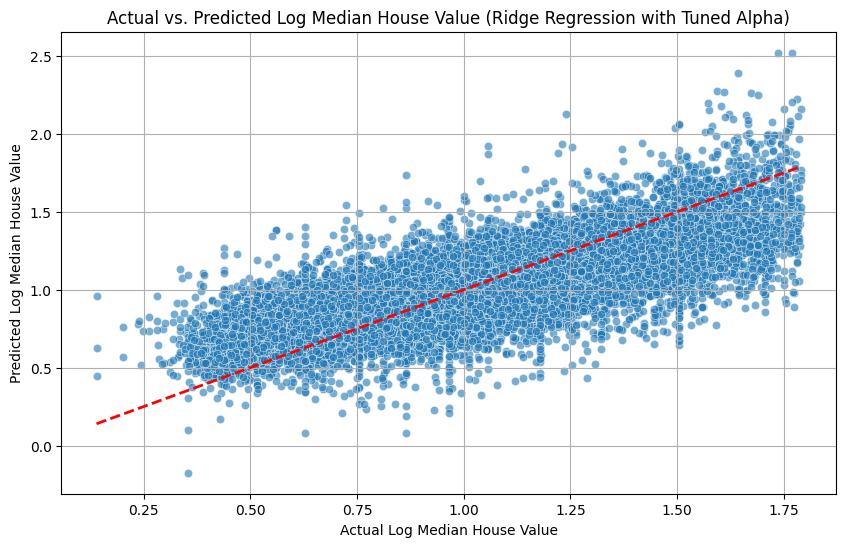

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ridge_actual_tuned, y=ridge_pred_tuned, alpha=0.6)
plt.plot([min(ridge_actual_tuned), max(ridge_actual_tuned)], [min(ridge_actual_tuned), max(ridge_actual_tuned)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Log Median House Value (Ridge Regression with Tuned Alpha)')
plt.xlabel('Actual Log Median House Value')
plt.ylabel('Predicted Log Median House Value')
plt.grid(True)
plt.show()


------

### Evaluation and Limitations


*   **Model Selection:** The final model choice was guided by stability and reliability rather than purely goodness-of-fit. Although OLS achieved a higher $R^2$, its violation of assumptions made it less dependable. The Bisquare robust regression, supported by Ridge regularization, was selected as the final approach because it produced consistent coefficients, handled outliers effectively, and maintained reasonable predictive performance.

* **Alternative Approaches**: Several alternative methods could further improve the analysis. Nonlinear models such as tree-based methods or kernel-based approaches could capture complex relationships that linear models cannot. Additionally, spatial models could explicitly account for geographic dependence, which is highly relevant in housing price data.
*  The data has lack of features like crime rates, school quality, local amenities, current economic indicators and other features that might affect the Housing prices.

*   **Model Assumptions:** The models in this analysis rely on key assumptions, including linearity, independence of observations, and normally distributed residuals. While preprocessing and transformations helped partially satisfy these assumptions, some violations remain, particularly in residual normality and potential spatial dependence. The results should be interpreted with these limitations in mind.

*   **Alternative Approaches:** Suggest other modeling techniques that could be tried (e.g., tree-based models like Random Forest or Gradient Boosting, or more advanced spatial regression models given your `Location_PCA`).

*   **Feature Engineering Extensions:** The analysis included feature engineering steps, such as creating the BedrmsPerRoom ratio and applying PCA to geographic coordinates. However, additional improvements could be explored. Example, interaction terms between income and location, or nonlinear transformations of variables, may capture more complex relationships. More advanced spatial features or clustering-based location indicators could also improve the models ability to explain housing price variation.

*   **Generalizability:** The results of this analysis are based on in-sample evaluation and may not fully reflect performance on unseen data. While the models were refined to improve robustness, their generalizability is not guaranteed without extensive out-of-sample validation. Additionally, the dataset represents a specific time period and geographic scope. Changes in economic conditions, policy, or housing demand may limit the applicability of the model to future data or different regions.

----
-----

### Comparing Ridge and HuberRegressor Coefficients

Let's compare the coefficients obtained from the tuned `statsmodels` Ridge Regression (which was built upon the Bisquare weighted RLM) and the `sklearn` HuberRegressor. This comparison will highlight any differences in how the models weigh each feature after their respective fitting processes.

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define target and features from the 'df' DataFrame
target_col = 'LogMedHouseVal'
features_list = ['MedInc', 'HouseAge', 'BedrmsPerRoom', 'LogPopulation',
                 'LogAveOccup', 'Location_PCA']

X = df[features_list]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(
    StandardScaler(),
    HuberRegressor(alpha=1.0, epsilon=1.35)
)

# Fit the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance on the test set
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"HuberRegressor Test R-squared: {r2:.4f}")
print(f"HuberRegressor Test RMSE: {rmse:.4f}")

# Get the stable coefficients from the HuberRegressor step in the pipeline
coefs = model.named_steps['huberregressor'].coef_
intercept = model.named_steps['huberregressor'].intercept_

params_df= pd.DataFrame(coefs)
print(f"Stable Coefficients: {params_df}")
print(f"Intercept: {intercept}")

HuberRegressor Test R-squared: 0.5544
HuberRegressor Test RMSE: 0.2171
Stable Coefficients:           0
0  0.300391
1  0.070795
2  0.109734
3  0.034027
4 -0.082811
5  0.015612
Intercept: 1.0108572048369016


In [40]:
ridge_coefficients = params_df_tuned['Coefficients']

huber_coef_names = ['MedInc', 'HouseAge', 'BedrmsPerRoom', 'LogPopulation', 'LogAveOccup', 'Location_PCA']
huber_coefficients_dict = dict(zip(huber_coef_names, coefs))
huber_coefficients_dict['const'] = intercept
huber_coefficients = pd.Series(huber_coefficients_dict)

# Reindex Huber coefficients to match Ridge for proper comparison
huber_coefficients = huber_coefficients.reindex(ridge_coefficients.index)

comparison_df = pd.DataFrame({
    'Ridge Coefficients': ridge_coefficients,
    'HuberRegressor Coefficients': huber_coefficients
})

print("Comparison of Coefficients:")
display(comparison_df)

Comparison of Coefficients:


,Ridge Coefficients,HuberRegressor Coefficients
const,1.012832,1.010857
MedInc,0.303929,0.300391
HouseAge,0.070567,0.070795
BedrmsPerRoom,0.115484,0.109734
LogPopulation,0.034322,0.034027
LogAveOccup,-0.084196,-0.082811
Location_PCA,0.014785,0.015612


<Figure size 1200x700 with 0 Axes>

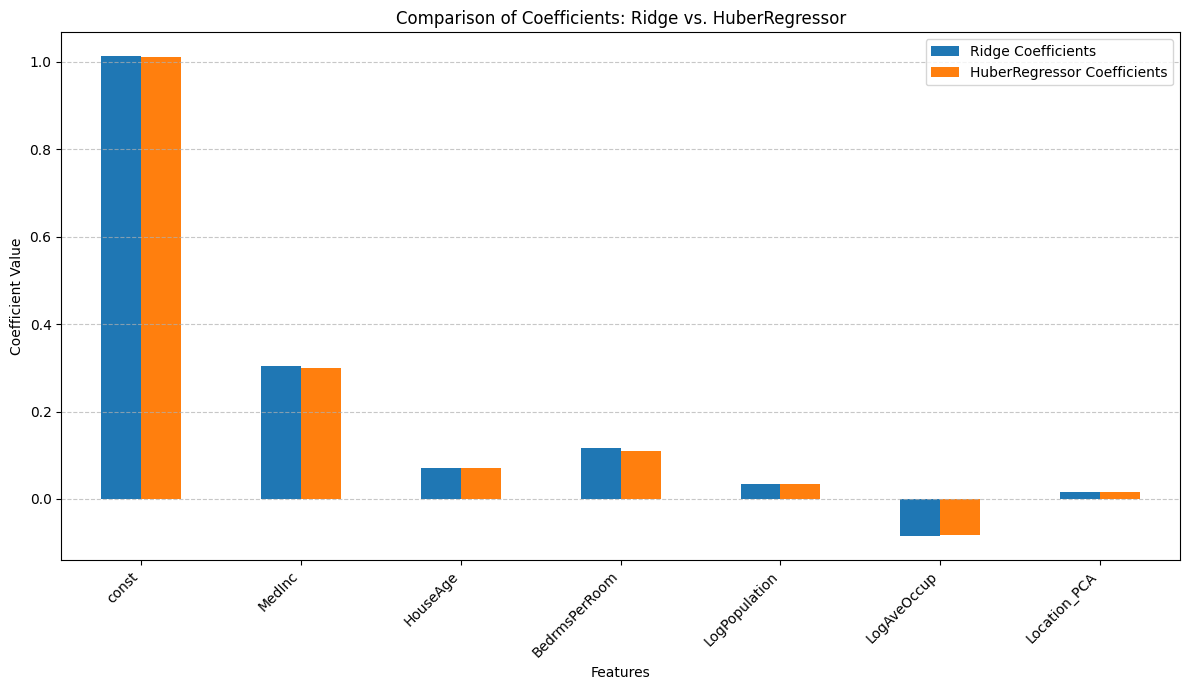

In [41]:
plt.figure(figsize=(12, 7))
comparison_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparison of Coefficients: Ridge vs. HuberRegressor')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()